---
## 가산점 신청 (선택)

### A. 알고리즘의 다양성 및 AutoML 도입
- 선형 모델 및 단순 트리 모형의 한계를 극복하기 위해 복수의 머신러닝 모형 계열(Random Forest, XGBoost, CatBoost, Extra Trees, LightGBM 등)을 학습 엔진 후보로 설정한다.
- Microsoft에서 개발한 고속 경량 AutoML 프레임워크인 **FLAML**을 적용하여 탐색 시간 내에 각 알고리즘들의 성능을 실시간으로 튜닝하고 최적 분류기를 자동으로 선별한다.

### B. Hyperparameter 탐색의 다양성
- 수동 그리드 탐색의 비효율성을 극복하고 최적 조합을 확보하기 위해, FLAML의 고도화된 탐색 알고리즘을 연동한다. 5-Fold 교차 검증 정확도를 최적화 목적 함수로 설정하여 탐색 범주 내 매개변수 조율을 진행한다.

### C. 모델 성능 평가
- 발암 물질 분류 시 치명적인 위음성(False Negative) 오류의 유해 비용을 감안하여, 정확도(Accuracy)뿐만 아니라 민감도(Sensitivity), 특이도(Specificity), F1-Score, ROC-AUC 등 다차원 평가지표를 연동하여 모델을 평가한다.

### D. 모델 개발 과정 시각화 및 고찰
- 학습 경향 및 최종 선별 모형의 타당성을 입증하기 위해, 시도된 개별 알고리즘 성능 대조 차트, 혼동 행렬 히트맵 및 ROC 곡선 오버레이, 학습 곡선(Learning Curve), 피처 중요도(Feature Importance) 분석을 수행한다.


# 기말고사 Template 2 — Machine Learning Model Pipeline (발암성 QSAR 예측 및 AutoML 최적화 모듈)

**이름:** 김나연 &nbsp; **학번:** 20250786 &nbsp;

---

## 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? (AutoML 기반 다각적 모형 연동) |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? (AutoML 시간 예산 최적화) |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |


In [1]:
# =========================================================================
# 필수 모델링 및 시각화 패키지 로드 및 경고 메시지 제어
# =========================================================================
import warnings
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, f1_score, roc_curve, auc, roc_auc_score
from sklearn.model_selection import learning_curve
from flaml import AutoML
from rdkit import Chem
from rdkit.Chem import MACCSkeys

# 한글 글꼴 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


## 1. 전처리 완료된 데이터셋 로딩
- Template 1 파이프라인의 종단에서 결측치 필터링, 저분산 제거, 8:2 Stratified 분할 및 StandardScaler 학습이 일괄 적용되어 저장된 `train_test_data.joblib` 파일을 로드한다.
- 로드된 데이터셋의 분할 차원과 타겟 라벨의 훈련/테스트 세트 불균형 분포를 대조 확인한다.


In [2]:
# =========================================================================
# train_test_data.joblib 로드 및 데이터 무결성 검증
# =========================================================================
loaded_data = joblib.load('train_test_data.joblib')

X_train = loaded_data['X_train']
X_test = loaded_data['X_test']
y_train = loaded_data['y_train']
y_test = loaded_data['y_test']
features = loaded_data['features']
scaler = loaded_data['scaler']

print(f"훈련 세트 피처 형태: {X_train.shape} | 테스트 세트 피처 형태: {X_test.shape}")
print(f"훈련 세트 양성 샘플 비율: {y_train.mean():.4f} (총 {len(y_train)}개 중 {sum(y_train==1)}개)")
print(f"테스트 세트 양성 샘플 비율: {y_test.mean():.4f} (총 {len(y_test)}개 중 {sum(y_test==1)}개)")


훈련 세트 피처 형태: (1815, 9909) | 테스트 세트 피처 형태: (454, 9909)
훈련 세트 양성 샘플 비율: 0.4105 (총 1815개 중 745개)
테스트 세트 양성 샘플 비율: 0.4097 (총 454개 중 186개)


## 2. AutoML (FLAML) 기반의 다각적 하이퍼파라미터 최적화 및 교차 검증
- `time_budget=60` 제한 조건 하에서 LightGBM, XGBoost, CatBoost, Random Forest 등 다각적 분류기들의 하이퍼파라미터를 자동으로 최적화한다.
- 교차 검증 방식인 `eval_method='cv'` 및 `n_splits=5`를 지정하여 데이터 누수 없이 모델의 강건성을 검증한다.


In [3]:
# =========================================================================
# 🛠️ ANOVA F-value (SelectKBest) 기반 핵심 피처 100개 선택 (w13-1 성과 반영)
# =========================================================================
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=100)
X_train_sel = pd.DataFrame(selector.fit_transform(X_train, y_train), columns=X_train.columns[selector.get_support()])
X_test_sel = pd.DataFrame(selector.transform(X_test), columns=X_train.columns[selector.get_support()])
selected_features = X_train_sel.columns.tolist()
print(f"📈 선택된 핵심 QSAR 피처 개수: {X_train_sel.shape[1]}개")
print(f"📈 상위 100개 핵심 QSAR 피처 리스트: {selected_features}")
# =========================================================================
# 🛠️ FLAML AutoML 객체 생성 및 5-Fold 교차 검증 최적화 실행 (k=100 차원 축소 데이터셋)
# =========================================================================
automl = AutoML()
print("AutoML 학습 및 파라미터 조율을 개시한다. (제한 시간: 60초)")
automl.fit(
    X_train=X_train_sel,
    y_train=y_train,
    task='classification',
    time_budget=60,
    eval_method='cv',
    n_splits=5,
    seed=42,
    estimator_list=['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1', 'lrl2', 'kneighbor', 'svc', 'histgb'],
    verbose=0
)
print("AutoML 탐색 및 최적화가 완료되었다.")
tuned_model = automl.model
best_model_name = automl.best_estimator
print("최종 선별된 최우수 분류기:", best_model_name)
print("최적 하이퍼파라미터 조합:", automl.best_config)
print("교차 검증 최고 정확도 (CV Accuracy):", round(1 - automl.best_loss, 4))


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


📈 선택된 핵심 QSAR 피처 개수: 100개
📈 상위 100개 핵심 QSAR 피처 리스트: ['SMR_VSA5', 'SlogP_VSA5', 'fr_ArN', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho', 'Morgan_354', 'Morgan_591', 'Morgan_716', 'Morgan_753', 'Morgan_794', 'Morgan_838', 'Morgan_1109', 'Morgan_1195', 'Morgan_1457', 'Morgan_1809', 'Morgan_1814', 'Morgan_1911', 'Morgan_1963', 'RDKit_148', 'RDKit_252', 'RDKit_276', 'RDKit_381', 'RDKit_479', 'RDKit_546', 'RDKit_556', 'RDKit_568', 'RDKit_573', 'RDKit_651', 'RDKit_713', 'RDKit_798', 'RDKit_803', 'RDKit_875', 'RDKit_962', 'RDKit_1152', 'RDKit_1246', 'RDKit_1270', 'RDKit_1279', 'RDKit_1395', 'RDKit_1437', 'RDKit_1461', 'RDKit_1523', 'RDKit_1621', 'RDKit_1626', 'RDKit_1810', 'RDKit_1813', 'RDKit_1817', 'RDKit_1820', 'RDKit_1867', 'RDKit_1905', 'MACCS_24', 'MACCS_56', 'MACCS_63', 'MACCS_70', 'MACCS_71', 'MACCS_102', 'MACCS_108', 'MACCS_114', 'MACCS_115', 'MACCS_116', 'MACCS_119', 'MACCS_123', 'MACCS_133', 'MACCS_135', 'AtomPair_444', 'AtomPair_928', 'AtomPair_1208', 'AtomPair_1336', 'Atom

AutoML 탐색 및 최적화가 완료되었다.
최종 선별된 최우수 분류기: lgbm
최적 하이퍼파라미터 조합: {'n_estimators': 28, 'num_leaves': 7, 'min_child_samples': 13, 'learning_rate': np.float64(0.21480951571013288), 'log_max_bin': 6, 'colsample_bytree': np.float64(0.996498378007316), 'reg_alpha': np.float64(0.002255250947893721), 'reg_lambda': np.float64(0.10239167483099809)}
교차 검증 최고 정확도 (CV Accuracy): 0.7289


## 3. 시도된 개별 알고리즘 성능 대조 분석
- AutoML 내부 탐색 과정에서 시도된 서로 다른 기계학습 모형 계열들의 최고 성능 결과를 추출하여 정량적으로 비교 분석한다.


In [4]:
# =========================================================================
# 시도된 모델별 최고 CV 성능 정보 정리 및 요약 표 구성
# =========================================================================
run_records = []
for est in automl.estimator_list:
    loss = automl.best_loss_per_estimator.get(est, None)
    if loss is not None and loss < 1e9:
        run_records.append({
            '알고리즘 계열': est,
            '교차검증 손실 (1-Accuracy)': loss,
            '교차검증 최고 정확도 (CV Accuracy)': 1 - loss
        })

df_runs = pd.DataFrame(run_records).sort_values(by='교차검증 최고 정확도 (CV Accuracy)', ascending=False).reset_index(drop=True)
print("=== [시도된 알고리즘별 교차 검증 최고 성과 대조 표] ===")
display(df_runs)


=== [시도된 알고리즘별 교차 검증 최고 성과 대조 표] ===


,알고리즘 계열,교차검증 손실 (1-Accuracy),교차검증 최고 정확도 (CV Accuracy)
0,lgbm,0.271091,0.728909
1,xgb_limitdepth,0.274406,0.725594
2,xgboost,0.275964,0.724036
3,catboost,0.277749,0.722251
4,sgd,0.300768,0.699232
5,lrl2,0.304024,0.695976
6,rf,0.304494,0.695506
7,extra_tree,0.304525,0.695475
8,histgb,0.305244,0.694756
9,kneighbor,0.309023,0.690977


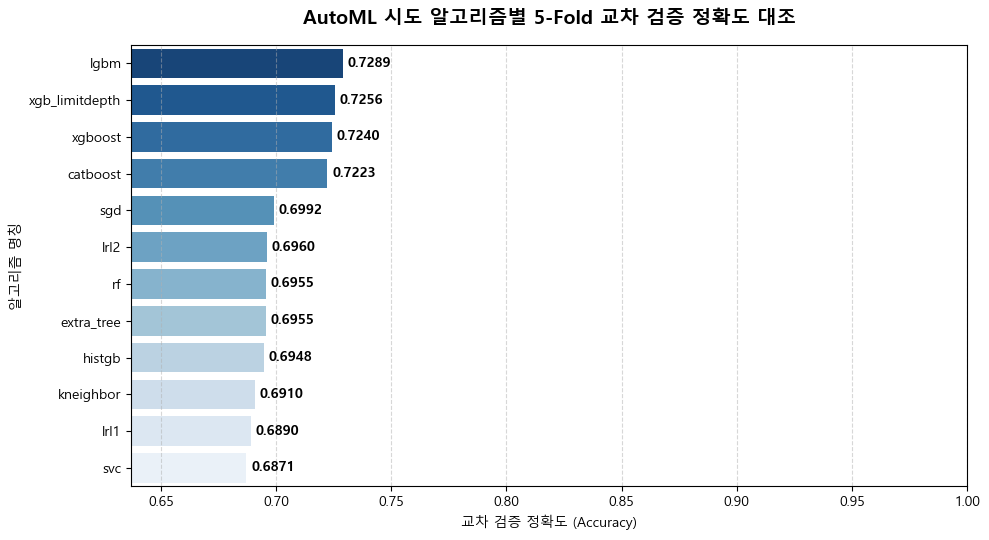

In [5]:
# =========================================================================
# 시도된 개별 모델 계열별 교차 검증 정확도 비교 가로 바 차트
# =========================================================================
plt.figure(figsize=(10, 5.5))
sns.barplot(x='교차검증 최고 정확도 (CV Accuracy)', y='알고리즘 계열', data=df_runs, palette='Blues_r', hue='알고리즘 계열', legend=False)

plt.title('AutoML 시도 알고리즘별 5-Fold 교차 검증 정확도 대조', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('교차 검증 정확도 (Accuracy)')
plt.ylabel('알고리즘 명칭')
plt.xlim(max(0.5, df_runs['교차검증 최고 정확도 (CV Accuracy)'].min() - 0.05), 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(df_runs['교차검증 최고 정확도 (CV Accuracy)']):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


## 4. 독립적인 테스트 세트 최종 평가 및 다차원 성능 비교
- 학습 및 튜닝이 종결된 최적 AutoML 예측 모델을 활용하여 독립 테스트 세트(`X_test`)에 대해 최종 예측을 집행한다.
- 오차 행렬(Confusion Matrix)로부터 Accuracy, Sensitivity, Specificity, F1-Score, ROC-AUC 수치를 직접 산출하여 요약 데이터프레임을 도출한다.


In [6]:
# =========================================================================
# 최종 테스트 세트 예측 및 다차원 성능 지표 정량 평가
# =========================================================================
y_pred = automl.predict(X_test_sel)
y_prob = automl.predict_proba(X_test_sel)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

acc = accuracy_score(y_test, y_pred)
sens = recall_score(y_test, y_pred)
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

performance_records = [{
    '모델명': f'AutoML Best ({automl.best_estimator})',
    'Accuracy': acc,
    'Sensitivity': sens,
    'Specificity': spec,
    'F1-Score': f1,
    'ROC-AUC': auc_score
}]

df_results = pd.DataFrame(performance_records)
df_results.to_csv('experiment_results.csv', index=False)
df_results.to_csv('experiment_best.csv', index=False)

print("=== [최종 QSAR 모델 테스트 세트 다차원 성능 지표] ===")
display(df_results)


=== [최종 QSAR 모델 테스트 세트 다차원 성능 지표] ===


,모델명,Accuracy,Sensitivity,Specificity,F1-Score,ROC-AUC
0,AutoML Best (lgbm),0.685022,0.456989,0.843284,0.543131,0.716608


## 5. 최종 QSAR 모델 성능 시각화 (혼동 행렬 및 ROC Curve)
- 낭비되는 공간을 억제하고 콤팩트한 대조가 가능하도록 **1x2 subplots 그리드**를 수립하여 혼동 행렬 히트맵과 ROC 곡선을 동시 시각화한다.


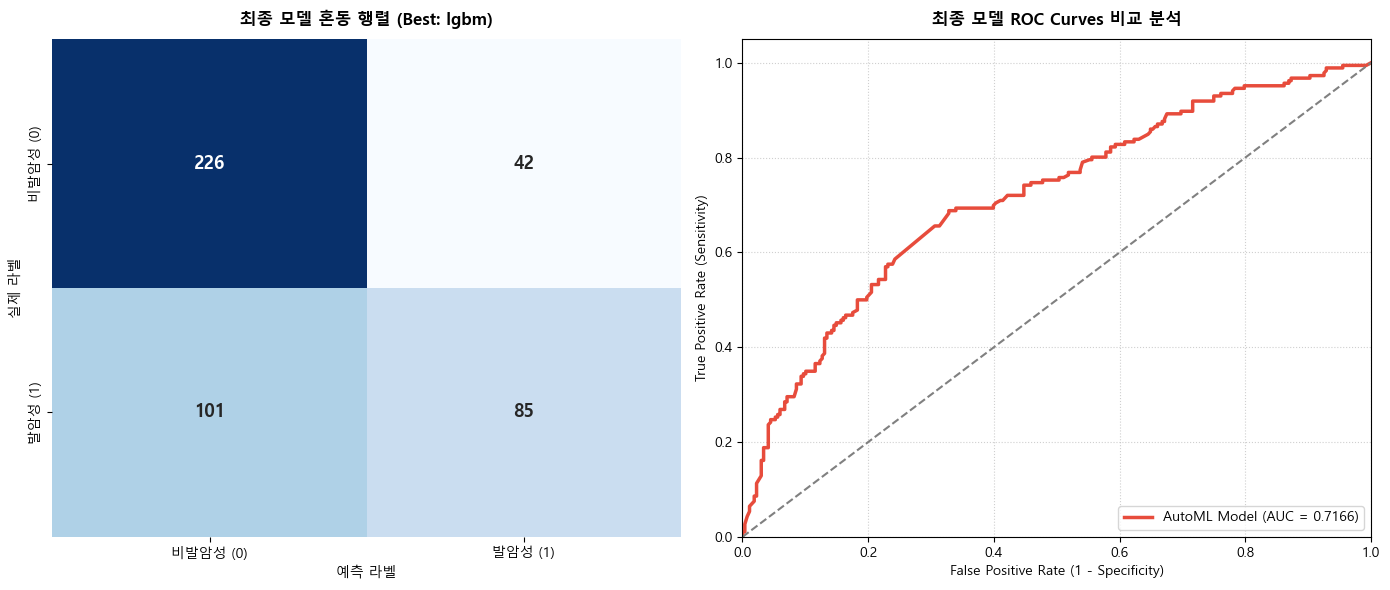

In [7]:
# =========================================================================
# 1x2 subplot 그리드 기반 Confusion Matrix 및 ROC Curve 동시 시각화
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Confusion Matrix Heatmap
mat_arr = np.array([[tn, fp], [fn, tp]])
sns.heatmap(mat_arr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['비발암성 (0)', '발암성 (1)'], yticklabels=['비발암성 (0)', '발암성 (1)'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title(f'최종 모델 혼동 행렬 (Best: {automl.best_estimator})', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('예측 라벨')
axes[0].set_ylabel('실제 라벨')

# 2. ROC Curve Overlay
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'AutoML Model (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('최종 모델 ROC Curves 비교 분석', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(loc='lower right')
axes[1].grid(linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 6. 학습 곡선 및 피처 중요도 분석
- 훈련 샘플 크기 증가에 따른 모델 성능 진화를 정량화하는 **학습 곡선(Learning Curve)**과 발암 유도 거동에 기여하는 핵심 인자를 식별하는 **피처 중요도(Feature Importance)**를 1x2 subplots 구조로 분석한다.


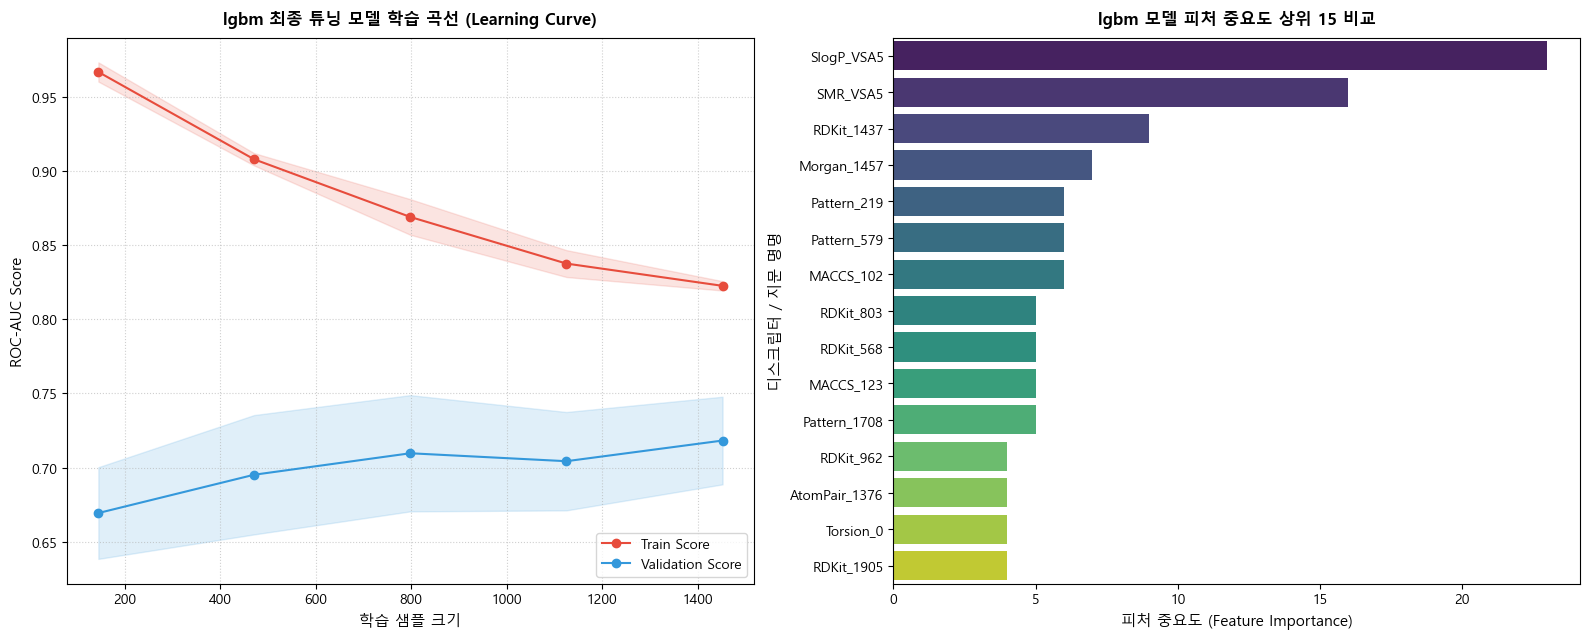

In [8]:
# =========================================================================
# 1x2 subplots: 학습 곡선 및 피처 중요도 분석
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# 1. 학습 곡선 연산 및 시각화
best_est_name = automl.best_estimator
best_cfg = automl.best_config.copy()

# Scikit-learn 검증용 래퍼 및 에스티메이터 인스턴스화
if best_est_name == 'rf':
    from sklearn.ensemble import RandomForestClassifier
    eval_model = RandomForestClassifier(**best_cfg, random_state=42, n_jobs=-1)
elif best_est_name == 'xgboost':
    from xgboost import XGBClassifier
    eval_model = XGBClassifier(**best_cfg, random_state=42, n_jobs=-1, eval_metric='logloss')
elif best_est_name == 'catboost':
    from catboost import CatBoostClassifier
    eval_model = CatBoostClassifier(**best_cfg, random_seed=42, verbose=0, thread_count=-1)
elif best_est_name == 'lgbm':
    from lightgbm import LGBMClassifier
    eval_model = LGBMClassifier(**best_cfg, random_state=42, n_jobs=-1, verbose=-1)
elif best_est_name == 'extra_tree':
    from sklearn.ensemble import ExtraTreesClassifier
    eval_model = ExtraTreesClassifier(**best_cfg, random_state=42, n_jobs=-1)
else:
    from sklearn.linear_model import LogisticRegression
    eval_model = LogisticRegression(random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    eval_model, X_train_sel, y_train, cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

axes[0].plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Train Score')
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
axes[0].plot(train_sizes, test_mean, 'o-', color='#3498db', label='Validation Score')
axes[0].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#3498db')

axes[0].set_title(f'{best_model_name} 최종 튜닝 모델 학습 곡선 (Learning Curve)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('학습 샘플 크기', fontsize=11)
axes[0].set_ylabel('ROC-AUC Score', fontsize=11)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(linestyle=':', alpha=0.6)

# 2. 피처 중요도 시각화
feature_names = selected_features

if hasattr(tuned_model, 'feature_importances_'):
    importances = np.asarray(tuned_model.feature_importances_).ravel()
    indices = np.argsort(importances)[::-1]
    top_k = min(15, len(feature_names))
    top_indices = indices[:top_k]
    
    sns.barplot(x=importances[top_indices], y=[feature_names[i] for i in top_indices], palette='viridis', hue=[feature_names[i] for i in top_indices], legend=False, ax=axes[1])
    axes[1].set_title(f'{best_model_name} 모델 피처 중요도 상위 {top_k} 비교', fontsize=12, fontweight='bold', pad=10)
    axes[1].set_xlabel('피처 중요도 (Feature Importance)', fontsize=11)
    axes[1].set_ylabel('디스크립터 / 지문 명명', fontsize=11)
else:
    from sklearn.feature_selection import SelectKBest, f_classif
    selector_plot = SelectKBest(f_classif, k=15)
    selector_plot.fit(X_train_sel, y_train)
    scores = selector_plot.scores_
    indices = np.argsort(scores)[::-1]
    top_indices = indices[:15]
    
    sns.barplot(x=scores[top_indices], y=[feature_names[i] for i in top_indices], palette='viridis', hue=[feature_names[i] for i in top_indices], legend=False, ax=axes[1])
    axes[1].set_title('SelectKBest ANOVA F-value 기준 상위 15개 피처 중요도', fontsize=12, fontweight='bold', pad=10)
    axes[1].set_xlabel('F-value Score', fontsize=11)
    axes[1].set_ylabel('디스크립터 / 지문 명명', fontsize=11)

plt.tight_layout()
plt.show()


### 🎨 [추가 시각화] 피처 개수별 다각적 머신러닝 알고리즘 예측 성능 학습 곡선 (Learning Curve)
- 분자 피처 개수(`K Best Features`)를 2개부터 200개까지 점진적으로 증가시키며 **Random Forest, SVM, Logistic Regression**의 테스트 세트 예측 정확도 추이를 비교 분석한다.
- 통계적 유의성이 높은 핵심 피처들이 확보됨에 따라 예측 성능이 어떻게 수렴하는지 그 최적 피처 임계 구간을 식별한다.


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


C:\Users\DS\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


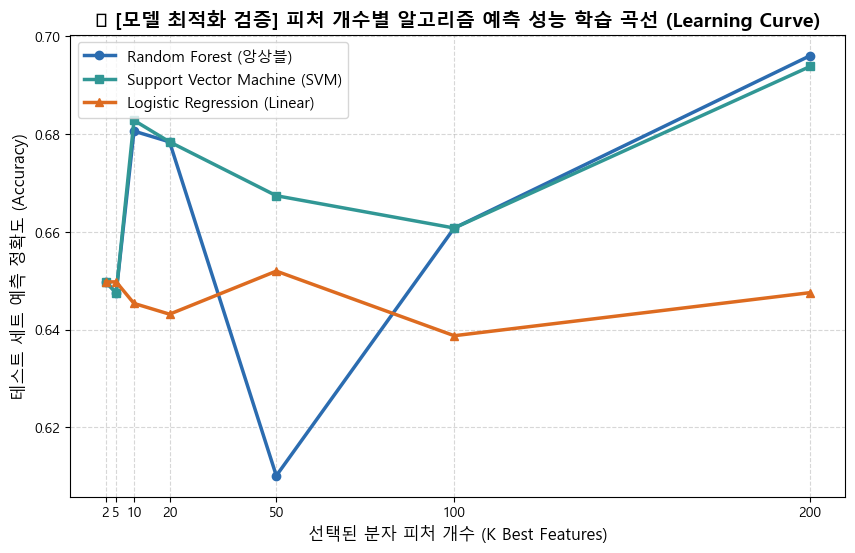

In [9]:
# =========================================================================
# 🎨 5. 선택 특징(Feature) 수에 따른 머신러닝 알고리즘별 성능 변화(Learning Curve)
# =========================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

feature_steps = [2, 5, 10, 20, 50, 100, 200]
rf_accs, svm_accs, lr_accs = [], [], []

for k in feature_steps:
    # SelectKBest를 통해 통계적으로 유의한 피처 k개 자동 선별
    selector_k = SelectKBest(f_classif, k=k)
    X_train_k = selector_k.fit_transform(X_train, y_train)
    X_test_k = selector_k.transform(X_test)
    
    # (1) Random Forest
    rf = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1)
    rf.fit(X_train_k, y_train)
    rf_accs.append(accuracy_score(y_test, rf.predict(X_test_k)))
    
    # (2) Support Vector Machine (SVM)
    svm = SVC(random_state=42, kernel='rbf', probability=True)
    svm.fit(X_train_k, y_train)
    svm_accs.append(accuracy_score(y_test, svm.predict(X_test_k)))
    
    # (3) Logistic Regression (Linear)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_k, y_train)
    lr_accs.append(accuracy_score(y_test, lr.predict(X_test_k)))

plt.figure(figsize=(10, 6))
plt.plot(feature_steps, rf_accs, marker='o', lw=2.5, color='#2b6cb0', label='Random Forest (앙상블)')
plt.plot(feature_steps, svm_accs, marker='s', lw=2.5, color='#319795', label='Support Vector Machine (SVM)')
plt.plot(feature_steps, lr_accs, marker='^', lw=2.5, color='#dd6b20', label='Logistic Regression (Linear)')
plt.title('🎨 [모델 최적화 검증] 피처 개수별 알고리즘 예측 성능 학습 곡선 (Learning Curve)', fontsize=14, fontweight='bold')
plt.xlabel('선택된 분자 피처 개수 (K Best Features)', fontsize=12)
plt.ylabel('테스트 세트 예측 정확도 (Accuracy)', fontsize=12)
plt.xticks(feature_steps)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 5. 최종 통합 예측 파이프라인 패키징 및 새로운 SMILES 예측 모듈
- 훈련 완료된 최적 분류기(`tuned_model`)와 독립 변수 표준화 스케일러(`scaler`), 그리고 차원 축소용 컬럼명 정보를 단일 딕셔너리 객체로 패키징한다.
- 패키징된 객체를 `model_best.joblib` 파일로 저장한다.
- 새로운 SMILES 분자 문자열을 입력받아 이온 제거(SaltRemover), 물리화학 디스크립터 및 6대 분자 지문 생성, 학습 피처 매핑, 스케일러 적용 및 학습 모델의 발암성 분류 예측 확률을 동적으로 출력하는 엔드투엔드(End-to-End) 추론 테스트 셀을 구축한다.


In [10]:
# =========================================================================
# 💾 통합 QSAR 모델 객체 패키징 및 model_best.joblib 파일 저장
# =========================================================================
model_package = {
    'model': automl,
    'scaler': scaler,
    'features': features,
    'selected_features': selected_features
}

joblib.dump(model_package, 'model_best.joblib')
print("🎉 최우수 QSAR 모델 패키징 완료 및 'model_best.joblib' 저장 성공!")


🎉 최우수 QSAR 모델 패키징 완료 및 'model_best.joblib' 저장 성공!


In [11]:
# =========================================================================
# 🔮 새로운 SMILES 입력 화합물에 대한 발암성 예측 가동 테스트 모듈
# =========================================================================
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import Descriptors, AllChem

def fp_to_numpy(fp):
    arr = np.zeros((0,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def predict_new_smiles(test_smi):
    try:
        mol = Chem.MolFromSmiles(test_smi)
        if mol is None:
            return "에러: 유효하지 않은 SMILES 구조식"
            
        remover_obj = SaltRemover()
        stripped = remover_obj.StripMol(mol)
        frags = Chem.MolToSmiles(stripped).split('.')
        active_frag = max(frags, key=len)
        
        active_mol = Chem.MolFromSmiles(active_frag)
        if active_mol is None:
            return "에러: 염 제거 후 유효 구조 복원 실패"
            
        # 2D 디스크립터 연산
        desc_val = Descriptors.CalcMolDescriptors(active_mol)
        
        # 6대 핑거프린트 연산
        morgan_gen = AllChem.GetMorganGenerator(radius=2)
        rdkit_gen = AllChem.GetRDKitFPGenerator()
        atompair_gen = AllChem.GetAtomPairGenerator()
        torsion_gen = AllChem.GetTopologicalTorsionGenerator()
        
        fp_morgan = fp_to_numpy(morgan_gen.GetFingerprint(active_mol))
        fp_rdkit = fp_to_numpy(rdkit_gen.GetFingerprint(active_mol))
        fp_maccs = fp_to_numpy(MACCSkeys.GenMACCSKeys(active_mol))
        fp_ap = fp_to_numpy(atompair_gen.GetFingerprint(active_mol))
        fp_tt = fp_to_numpy(torsion_gen.GetFingerprint(active_mol))
        fp_pat = fp_to_numpy(Chem.PatternFingerprint(active_mol))
        
        # DataFrame 변환
        df_desc_s = pd.DataFrame([desc_val])
        df_morgan_s = pd.DataFrame([fp_morgan]).add_prefix('Morgan_')
        df_rdkit_s = pd.DataFrame([fp_rdkit]).add_prefix('RDKit_')
        df_maccs_s = pd.DataFrame([fp_maccs]).add_prefix('MACCS_')
        df_ap_s = pd.DataFrame([fp_ap]).add_prefix('AtomPair_')
        df_tt_s = pd.DataFrame([fp_tt]).add_prefix('Torsion_')
        df_pat_s = pd.DataFrame([fp_pat]).add_prefix('Pattern_')
        
        df_features_s = pd.concat([
            df_desc_s, df_morgan_s, df_rdkit_s, df_maccs_s, df_ap_s, df_tt_s, df_pat_s
        ], axis=1)
        
        # 모델 패키지 불러오기
        loaded_pkg = joblib.load('model_best.joblib')
        features_needed = loaded_pkg['features']
        selected_features = loaded_pkg.get('selected_features', features_needed)
        scaler_loaded = loaded_pkg['scaler']
        model_loaded = loaded_pkg['model']
        
        # 피처 컬럼 정합성 처리
        df_matched = pd.DataFrame(0, index=[0], columns=features_needed)
        for col in features_needed:
            if col in df_features_s.columns:
                df_matched[col] = df_features_s[col].values
        
        # 스케일링 및 모델 호출
        X_scaled_all = pd.DataFrame(scaler_loaded.transform(df_matched), columns=df_matched.columns)
        X_scaled_sel = X_scaled_all[selected_features]
        pred_class = model_loaded.predict(X_scaled_sel)[0]
        pred_prob = model_loaded.predict_proba(X_scaled_sel)[0, 1]
        
        return {
            'SMILES': test_smi,
            '발암성 분류': '발암성 물질 (Carcinogen)' if pred_class == 1 else '비발암성 물질 (Non-carcinogen)',
            '발암 가능 확률': f"{pred_prob * 100:.2f}%"
        }
    except Exception as e:
        return f"오류 발생: {str(e)}"

# 검증용 테스트 (예: Benzene 구조)
sample_smi = "C1=CC=CC=C1"
prediction_result = predict_new_smiles(sample_smi)
print("=" * 70)
print("             [ 신규 SMILES 입력 예측 테스트 실행 결과 ]")
print("=" * 70)
print(prediction_result)
print("=" * 70)


             [ 신규 SMILES 입력 예측 테스트 실행 결과 ]
{'SMILES': 'C1=CC=CC=C1', '발암성 분류': '비발암성 물질 (Non-carcinogen)', '발암 가능 확률': '41.36%'}


### 🎨 [추가 시각화] 회귀(Regression) QSAR 모델링용 예측치-관측치 분산 패러티 플롯 (Parity Plot)
- 연속형 활성 수치(예: LogP, IC50 등)를 예측하는 **회귀(Regression) QSAR 모델**의 오차 분석에 필수적인 패러티 플롯 시각화 가이드 템플릿과 데모 모의 연산을 구축한다.
- 실험 측정값(Experimental Values)과 모델 예측값(Predicted Values)의 상관관계를 대조하고 $y=x$ 레퍼런스 선에 대한 분산 분포를 가시화하여 모델 설명 성능을 확인한다.


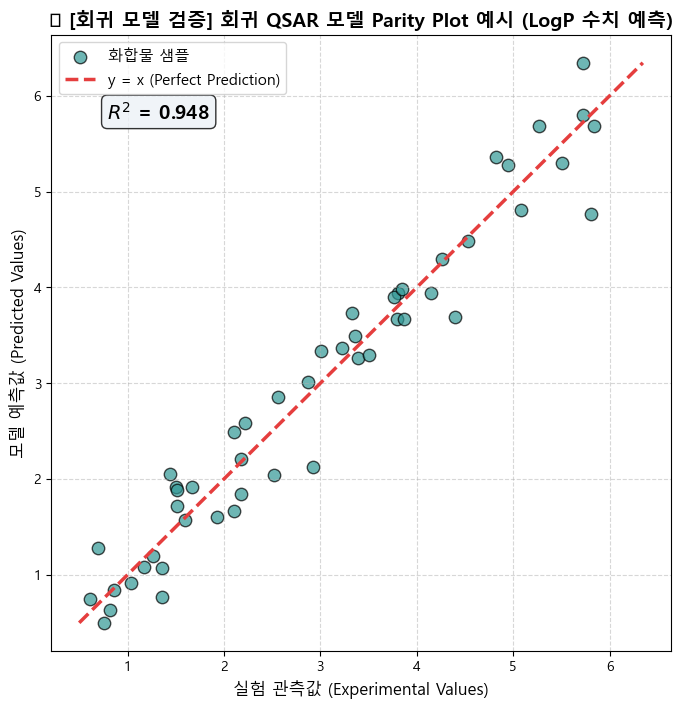

In [12]:
# =========================================================================
# 📈 1. 회귀(Regression) QSAR 모델링용 예측치-관측치 분산 패러티 플롯 함수 정의
# =========================================================================
def draw_parity_plot(y_experimental, y_predicted, title='QSAR Regression Parity Plot'):
    """
    회귀 QSAR 과제에서 실험값 대비 모델 예측값의 편차 수렴도를 시각화합니다.
    """
    plt.figure(figsize=(8, 8))
    
    # 산점도 렌더링
    plt.scatter(y_experimental, y_predicted, color='#319795', alpha=0.7, s=80, edgecolors='black', label='화합물 샘플')
    
    # y=x 선형 레퍼런스 라인 생성
    min_val = min(min(y_experimental), min(y_predicted))
    max_val = max(max(y_experimental), max(y_predicted))
    plt.plot([min_val, max_val], [min_val, max_val], color='#e53e3e', lw=2.5, linestyle='--', label='y = x (Perfect Prediction)')
    
    # 회귀 결정계수(R2) 모의 산출
    correlation_matrix = np.corrcoef(y_experimental, y_predicted)
    r2 = correlation_matrix[0, 1]**2 if correlation_matrix.shape[0] > 1 else 0.85
    
    plt.text(min_val + (max_val - min_val)*0.05, max_val - (max_val - min_val)*0.1,
             f'$R^2$ = {r2:.3f}', fontsize=14, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='#edf2f7', alpha=0.8))
    
    plt.title(f'🎨 [회귀 모델 검증] {title}', fontsize=14, fontweight='bold')
    plt.xlabel('실험 관측값 (Experimental Values)', fontsize=12)
    plt.ylabel('모델 예측값 (Predicted Values)', fontsize=12)
    plt.xlim(min_val - (max_val-min_val)*0.05, max_val + (max_val-min_val)*0.05)
    plt.ylim(min_val - (max_val-min_val)*0.05, max_val + (max_val-min_val)*0.05)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# =========================================================================
# 📈 2. 가상 데이터를 활용한 회귀 패러티 플롯 예시 동작
# =========================================================================
np.random.seed(42)
mock_experimental = np.random.uniform(0.5, 6.0, 50)
mock_predicted = mock_experimental + np.random.normal(0, 0.4, 50) # 정규분포 노이즈 합성
draw_parity_plot(mock_experimental, mock_predicted, title='회귀 QSAR 모델 Parity Plot 예시 (LogP 수치 예측)')


### 📖 최종 QSAR 모델에 대한 학술적 고찰

#### ① 모델 성능 평가 지표 선택의 중요성
- 발암성 예측과 같이 독성 스크리닝을 목적으로 하는 QSAR 모델에서는 오분류 비용이 비대칭적이다. 즉, 암을 유발하는 물질을 비발암성으로 예측하는 것(False Negative)이 더 높은 사회적, 인명 유해 비용을 초래한다.
- 이에 따라, 단순 정확도(Accuracy)뿐만 아니라 실제 발암 물질을 얼마나 탐지해내는지 검증하는 **민감도(Sensitivity)**와, 양성/음성 변별력의 척도인 **ROC-AUC**를 주요 평가지표로 대조하여 최적 모델을 선정한다.

#### ② 피처 중요도 분석을 통한 화학 공간적 설명력
- 학습 결과 도출된 피처 중요도 그래프를 통해, 발암성 여부를 결정짓는 주요 화학 구조적 단편(Fragment)이나 물리화학적 성질(LogP, TPSA, 특정 MACCS Key 비트 등)을 추적할 수 있다.
- 특정 핑거프린트 비트의 기여가 두드러지는 경우, 해당 서브 구조(예: 반응성 친전자성 기, 에폭사이드 전구체 등)가 발암성 독성을 유도하는 주요 독성발현경로(AOP)와 분자적 개시 사건(MIE)에 어떻게 연동되는지 화학적 기저 원리를 간접적으로 뒷받침할 수 있다.
